<a href="https://colab.research.google.com/github/Saatwik-Mehta/neural-nets-learning/blob/main/MicroGrad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import math
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label=label
    self.grad = 0.0

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = Value(other) if not isinstance(other, Value) else other
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += out.grad * 1
      other.grad += out.grad * 1
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = Value(other) if not isinstance(other, Value) else other
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * (other**-1)

  def __sub__(self, other):
    return self + (-other)

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      # Derivation of an expontial function
      # https://en.wikipedia.org/wiki/Exponential_function#:~:text=complex%20exponential%20is%20the,%E2%81%A0%3A
      self.grad = out.data * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float))
    out = Value(self.data**other, (self, ), f'**{other}')
    def _backward():
      self.grad = (other * (self.data**(other-1))) * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
        # Build the topological order of the computation graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # Base case: dL/dL = 1.0
        self.grad = 1.0

        # Backpropagate in reverse topological order
        for node in reversed(topo):
            node._backward()

In [14]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'


In [15]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [16]:
d._op

'+'

In [17]:
from graphviz import Digraph


def trace(root):
    """
    Traverse the computation graph starting from the root node.

    Collects all nodes and directed edges that contribute to the
    computation of the given root node.

    Args:
        root: The final node of the computation graph.

    Returns:
        tuple:
            nodes (set): All unique nodes in the computation graph.
            edges (set): All directed edges represented as (child, parent)
                         tuples, indicating dependencies between nodes.

    Note:
        Each node is expected to have a `_prev` attribute containing
        its immediate predecessor nodes.
    """
    nodes, edges = set(), set()

    def build(v):
        """
        Recursively visit a node and all its predecessor nodes.

        Args:
            v: The current node being visited.
        """
        # Avoid processing the same node multiple times.
        if v not in nodes:
            nodes.add(v)

            # Traverse all nodes that contributed to the current node.
            for child in v._prev:
                # Record the dependency: child -> current node.
                edges.add((child, v))

                # Recursively explore the child's dependencies.
                build(child)

    # Start traversing from the final computation node.
    build(root)

    return nodes, edges


def draw_dot(root):
    """
    Visualize a computation graph using Graphviz.

    Each value in the graph is represented as a record-shaped node.
    Operations are represented as separate nodes and connected to
    the values they produce.

    Args:
        root: The final node of the computation graph to visualize.

    Returns:
        Digraph: A Graphviz directed graph that can be rendered
                 or saved as an SVG file.

    Expected node attributes:
        data  : The numerical value stored in the node.
        label : A descriptive label for the node.
        _prev : A collection of predecessor nodes.
        _op   : The operation that produced the node, if applicable.

    Example:
        dot = draw_dot(result)
        dot.render("computation_graph", view=True)
    """

    # Create a directed graph.
    # rankdir="LR" arranges the graph from left to right.
    # format="svg" specifies the output format.
    dot = Digraph(
        format="svg",
        graph_attr={"rankdir": "LR"}
    )

    # Collect all nodes and dependency edges in the graph.
    nodes, edges = trace(root)

    # ---------------------------------------------------------
    # Step 1: Create nodes for values and their operations
    # ---------------------------------------------------------
    for n in nodes:

        # Use the object's unique identity as its Graphviz ID.
        # This prevents nodes with identical values from merging.
        uid = str(id(n))

        # Create a record-shaped node showing the label and value.
        # Example: { x | data 2.0000 }
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape="record"
        )

        # If the node was produced by an operation, create
        # a separate node representing that operation.
        if n._op:

            # Give the operation node a unique ID by combining
            # the value node's ID with the operation name.
            op_id = uid + n._op

            dot.node(
                name=op_id,
                label=n._op
            )

            # Connect the operation node to the value it produces.
            # Example: '+' -> result
            dot.edge(op_id, uid)

    # ---------------------------------------------------------
    # Step 2: Create edges representing computation dependencies
    # ---------------------------------------------------------
    for n1, n2 in edges:

        # Connect each predecessor value to the operation
        # that produces the dependent node.
        #
        # Example:
        #     x ----\
        #            + ----> result
        #     y ----/
        #
        # n1 is the input value.
        # n2 is the node produced using that input.
        dot.edge(
            str(id(n1)),
            str(id(n2)) + n2._op
        )

    # Return the graph object so the caller can render or save it.
    return dot

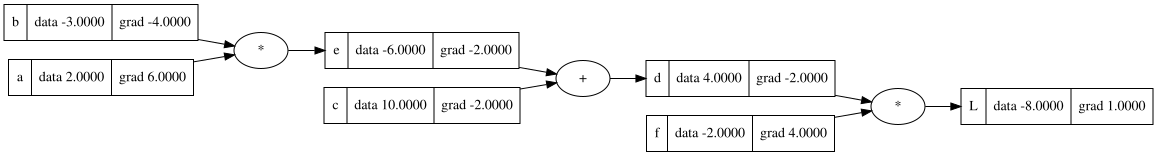

In [20]:
draw_dot(L)

In [19]:
L.backward()

In [43]:
a = Value(2.0)
a-2

Value(data=0.0)

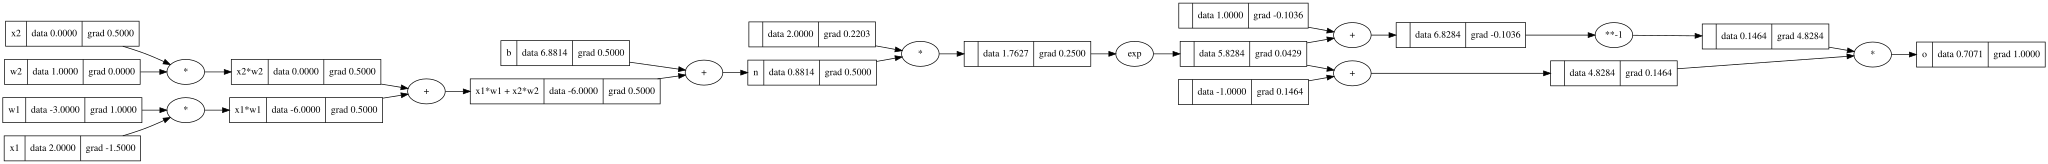

In [44]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# -----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# -----
o.label = 'o'
o.backward()
draw_dot(o)

In [49]:
import random
# Defining a Neuron
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    """
    x: input to neural network
    """
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

In [66]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.9942092888520718)

In [67]:
class Layer:
  def __init__(self, nin, nout):
    """
    nin: Number of inputs to a neuron
    nout: Number of neurons as output
    """
    self.neurons = [Neuron(nin) for _ in range(nout)]
  def __call__(self, x):
    return [n(x) for n in self.neurons]

In [70]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=-0.9781204321512958),
 Value(data=-0.17161860001695475),
 Value(data=-0.7860986333607586)]